# Token and Latency Analysis for Diffusion LLMs Evaluation

This notebook analyzes token usage and latency across every model under `results/`, while excluding `archive`.

It reports:
- average tokens per metric task
- global average tokens per call
- latency statistics

Each row in the latency CSVs represents one API call.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path("/Users/lokovacic/Projects/diffusion-llms-eval")
RESULTS_DIR = BASE / "results"
EXCLUDE_MODELS = {"archive"}

MODEL_DIRS = sorted(
    d for d in RESULTS_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDE_MODELS
)

print(f"Found {len(MODEL_DIRS)} models:")
for m in MODEL_DIRS:
    print(f"  {m.name}")

Found 7 models:
  LLaDA2.1-mini
  Qwen3.6-35B-A3B-FP8
  gemma-4-26b-a4b-it
  gemma-4-31b-it
  gemma-4-e2b-it
  gpt-4.1-mini
  qwen35-2b


---
## Helper Functions

In [2]:
def load_all_latency_data(model_dirs: list[Path]) -> pd.DataFrame:
    frames = []
    for model_dir in model_dirs:
        for csv_path in sorted(model_dir.glob("*_latency.csv")):
            df = pd.read_csv(csv_path)
            df = df.copy()
            df["model_dir"] = model_dir.name
            df["source_file"] = csv_path.name
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def p95(series: pd.Series) -> float:
    return series.quantile(0.95)

def round_df(df: pd.DataFrame, digits: int = 3) -> pd.DataFrame:
    return df.map(lambda x: round(x, digits) if isinstance(x, (float, np.floating)) else x)

---
## Load Token and Latency Data

In [3]:
latency_df = load_all_latency_data(MODEL_DIRS)
print(f"Loaded {len(latency_df)} call rows")
display(latency_df.head())
print("\nColumns:")
print(list(latency_df.columns))
print("\nModels:", sorted(latency_df['model'].dropna().unique()))
print("Metric tasks:", sorted(latency_df['metric_name'].dropna().unique()))

latency_overall_by_metric = (
    latency_df
    .groupby('metric_name')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)


Loaded 3082 call rows


,case_id,example_idx,question,metric_name,call_index,prompt,response_model,response,latency_s,prompt_tokens,completion_tokens,total_tokens,cached_tokens,reasoning_tokens,timestamp,model,model_dir,source_file
0,CR1,0,What is LLM-as-a-judge?,context_relevance,0,You are a world class expert designed to evalu...,ContextRelevanceOutput,rating=2,0.2495,868,13,881,0,0,2026-06-08T20:42:39.971211+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_224239_LLaDA2.1-mini_context-relevanc...
1,CR1,0,What is LLM-as-a-judge?,context_relevance,1,As a specially designed expert to assess the r...,ContextRelevanceOutput,rating=2,0.1548,858,13,871,0,0,2026-06-08T20:42:40.126295+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_224239_LLaDA2.1-mini_context-relevanc...
2,CR2,1,What is agent observability?,context_relevance,0,You are a world class expert designed to evalu...,ContextRelevanceOutput,rating=2,0.0624,786,13,799,0,0,2026-06-08T20:42:40.189571+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_224239_LLaDA2.1-mini_context-relevanc...
3,CR2,1,What is agent observability?,context_relevance,1,As a specially designed expert to assess the r...,ContextRelevanceOutput,rating=2,0.0617,776,13,789,0,0,2026-06-08T20:42:40.251661+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_224239_LLaDA2.1-mini_context-relevanc...
4,CR3,2,What is AI observability?,context_relevance,0,You are a world class expert designed to evalu...,ContextRelevanceOutput,rating=2,0.0763,822,13,835,0,0,2026-06-08T20:42:40.328570+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_224239_LLaDA2.1-mini_context-relevanc...



Columns:
['case_id', 'example_idx', 'question', 'metric_name', 'call_index', 'prompt', 'response_model', 'response', 'latency_s', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'cached_tokens', 'reasoning_tokens', 'timestamp', 'model', 'model_dir', 'source_file']

Models: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']
Metric tasks: ['answer_relevancy', 'context_relevance', 'context_utilization', 'faithfulness_exp1', 'faithfulness_exp2', 'response_groundedness']


---
## Average Tokens Per Metric Task

prompt_tokens                    \
                                                   mean  median       std   
model               metric_name                                             
LLaDA2.1-mini       answer_relevancy            735.100   732.5    16.992   
                    context_relevance          1413.500  1378.0   487.981   
                    context_utilization        1560.545  1646.0   570.562   
                    faithfulness_exp1          1514.425  1268.0  1573.169   
                    faithfulness_exp2          1856.634  1597.0  1017.238   
                    response_groundedness      1376.340  1363.5   441.231   
Qwen3.6-35B-A3B-FP8 answer_relevancy            724.100   721.5    16.941   
                    context_relevance          1308.810  1361.0   327.354   
                    faithfulness_exp1          1240.208   814.0   798.237   
                    faithfulness_exp2          1744.311  1622.0   433.719   
                    response_groundedness      1344.500  1349.5   391.895   
gemma-4-26b-a4b-it  answer_relevancy            756.567   754.0    16.856   
                    context_relevance          1342.500  1394.0   332.667   
                    context_utilization        1519.602  1625.5   171.603   
                    faithfulness_exp1          1217.944  1033.5   633.451   
                    faithfulness_exp2          1777.778  1639.0   444.788   
                    response_groundedness      1369.415  1383.0   394.752   
gemma-4-31b-it      answer_relevancy            756.567   754.0    16.856   
                    context_relevance          1342.500  1394.0   332.667   
                    context_utilization        1519.602  1625.5   171.603   
                    faithfulness_exp1          1224.089  1043.5   642.080   
                    faithfulness_exp2          1777.778  1639.0   444.788   
                    response_groundedness      1369.415  1383.0   394.752   
gemma-4-e2b-it      answer_relevancy            982.000   755.0   691.118   
                    context_relevance          2268.988  1481.0  1865.489   
                    context_utilization        1881.102  1668.5  1031.980   
                    faithfulness_exp1          2281.205  1551.5  2294.252   
                    faithfulness_exp2          2301.556  1824.0  1679.503   
                    response_groundedness      2605.989  1771.0  1817.102   
gpt-4.1-mini        answer_relevancy            673.500   671.0    17.156   
                    context_relevance          1247.476  1300.5   326.176   
                    context_utilization        1388.580  1492.5   164.181   
                    faithfulness_exp1          1130.311   951.0   607.133   
                    faithfulness_exp2          1897.911  1546.0  1148.492   
                    response_groundedness      1281.160  1284.5   388.493   
qwen35-2b           answer_relevancy            724.100   721.5    16.797   
                    context_relevance          1308.810  1361.0   327.354   
                    context_utilization        1493.943  1600.0   166.005   
                    faithfulness_exp1          1179.225   814.0   620.723   
                    faithfulness_exp2          1744.311  1622.0   436.176   
                    response_groundedness      1344.500  1349.5   391.895   

                                                completion_tokens         \
                                          count              mean median   
model               metric_name                                            
LLaDA2.1-mini       answer_relevancy         30            36.500   37.0   
                    context_relevance        84            13.238   13.0   
                    context_utilization      88            71.693   66.5   
                    faithfulness_exp1        87           432.437  244.0   
                    faithfulness_exp2        41           542.171  470.0   
                    response_groundedness    

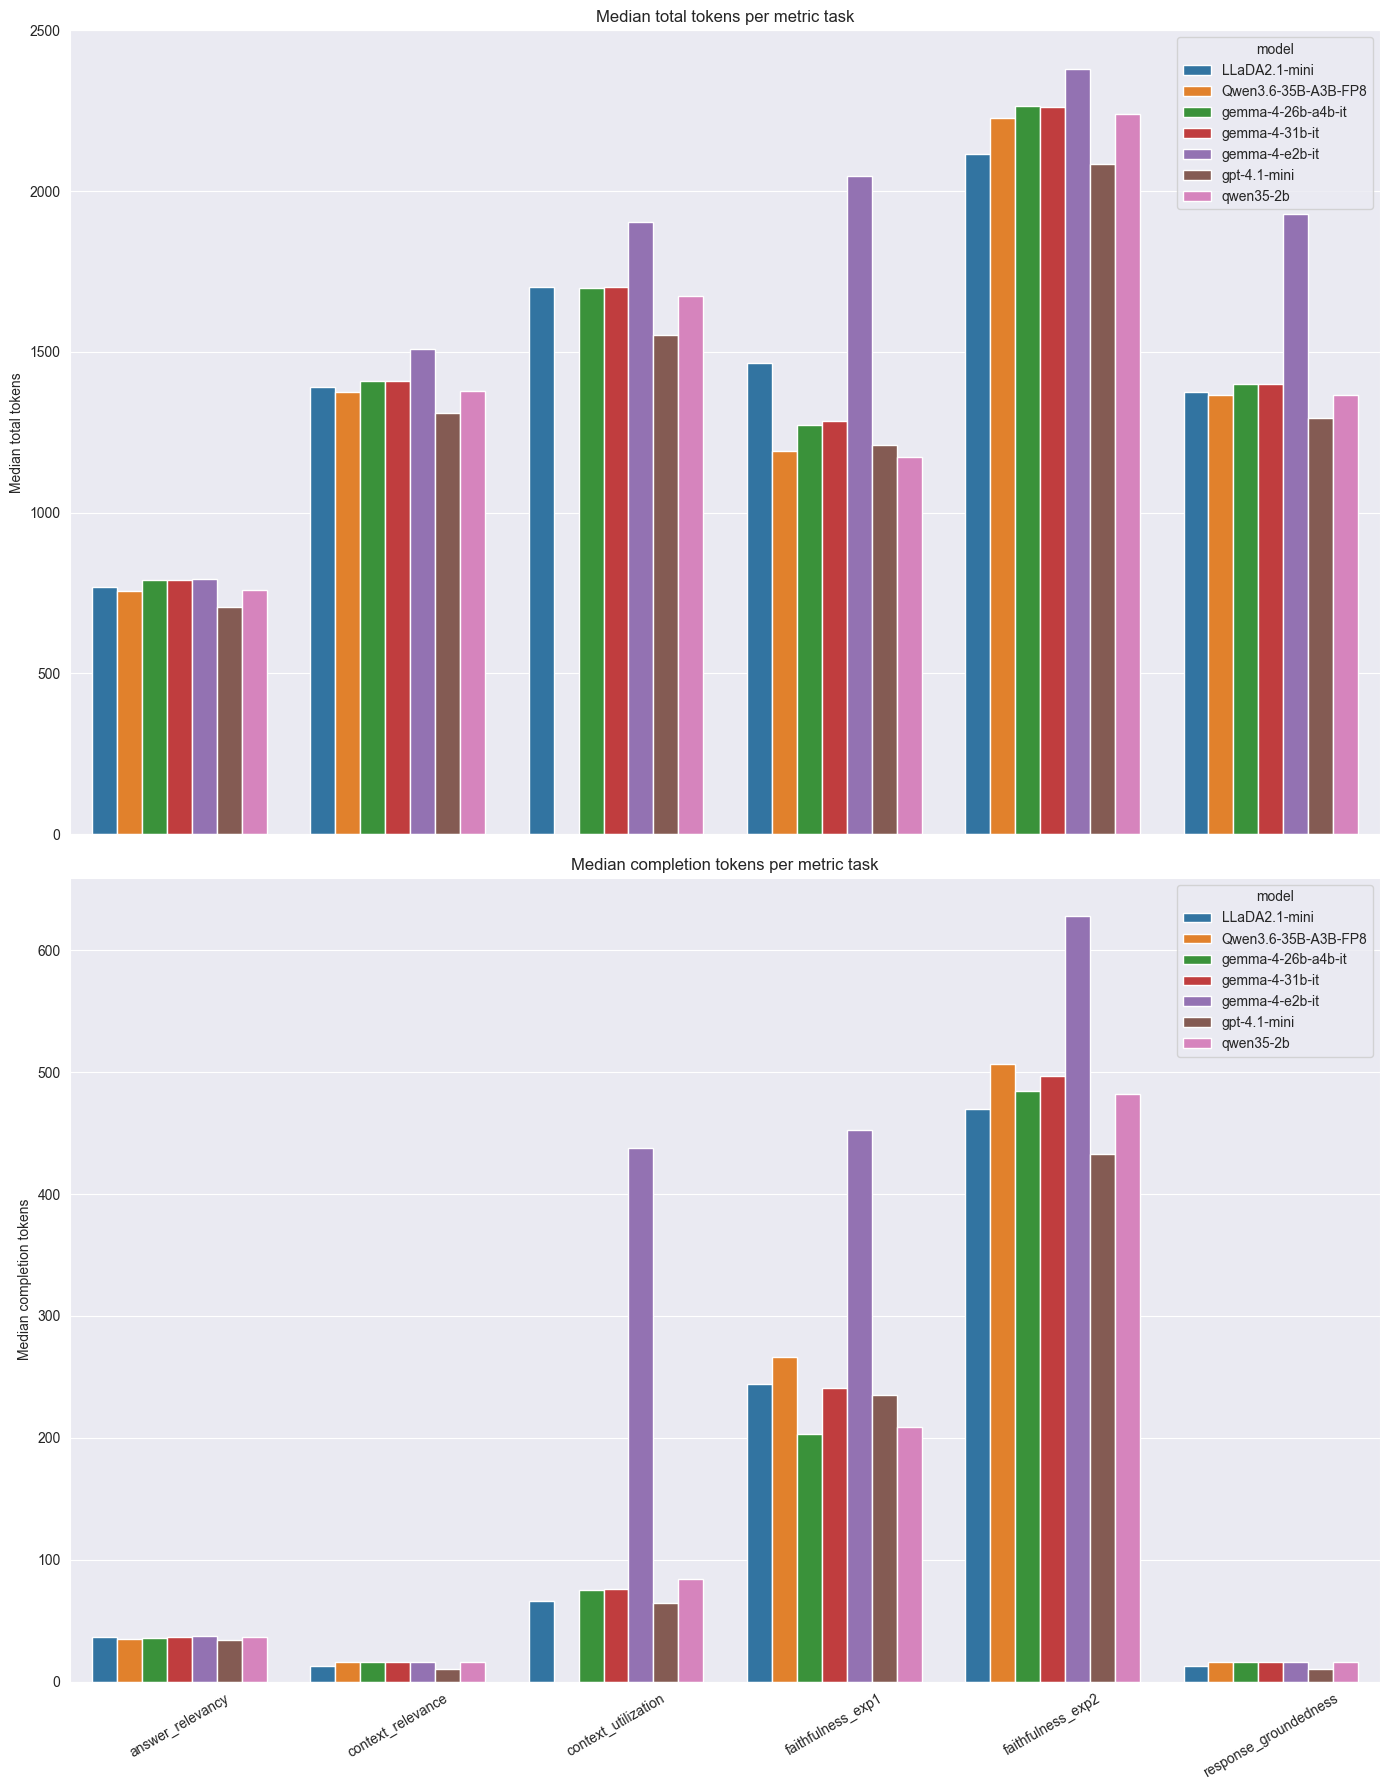

In [4]:
token_cols = [
    'prompt_tokens',
    'completion_tokens',
    'total_tokens',
    'cached_tokens',
    'reasoning_tokens',
]

task_token_summary = (
    latency_df
    .groupby(['model', 'metric_name'])[token_cols]
    .agg(['mean', 'median', 'std', 'count'])
    .sort_index()
)
display(round_df(task_token_summary))

task_token_means = (
    latency_df
    .groupby(['model', 'metric_name'], as_index=False)[token_cols]
    .median(numeric_only=True)
)

task_token_means_no_qwen = task_token_means[
    task_token_means['model'] != 'Qwen3.6-35B-A3B-FP8'
]

fig, axes = plt.subplots(2, 1, figsize=(14, 18), sharex=True)

sns.barplot(data=task_token_means, x='metric_name', y='total_tokens', hue='model', ax=axes[0])
axes[0].set_title('Median total tokens per metric task')
axes[0].set_xlabel('')
axes[0].set_ylabel('Median total tokens')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=task_token_means, x='metric_name', y='completion_tokens', hue='model', ax=axes[1])
axes[1].set_title('Median completion tokens per metric task')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median completion tokens')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()


---
## Global Average Tokens Per Call

prompt_tokens                         completion_tokens  \
                             mean  median       std count              mean   
model                                                                         
LLaDA2.1-mini            1451.340  1366.0   902.582   424           164.142   
Qwen3.6-35B-A3B-FP8      1335.695  1312.0   616.695   476           274.032   
gemma-4-26b-a4b-it       1363.183  1380.0   466.382   431           147.411   
gemma-4-31b-it           1364.466  1380.0   468.426   431           151.705   
gemma-4-e2b-it           2179.186  1581.0  1779.080   429           422.907   
gpt-4.1-mini             1287.125  1263.0   585.488   431           147.339   
qwen35-2b                1292.785  1321.5   470.083   460           145.770   

                                          total_tokens                    \
                    median      std count         mean  median       std   
model                                                                      
LLaDA2.1-mini         51.5  311.753   424     1615.481  1449.5  1125.756   
Qwen3.6-35B-A3B-FP8   94.0  369.804   476     1609.727  1425.5   905.510   
gemma-4-26b-a4b-it    54.0  240.362   431     1510.594  1458.0   627.198   
gemma-4-31b-it        50.0  248.206   431     1516.172  1460.0   634.703   
gemma-4-e2b-it       211.0  503.855   429     2602.093  1779.0  2154.899   
gpt-4.1-mini          46.0  259.607   431     1434.464  1335.0   768.527   
qwen35-2b             42.0  243.296   460     1438.554  1410.0   633.491   

                          cached_tokens                        \
                    count          mean median      std count   
model                                                           
LLaDA2.1-mini         424         0.000    0.0    0.000   424   
Qwen3.6-35B-A3B-FP8   476         0.000    0.0    0.000   476   
gemma-4-26b-a4b-it    431         0.000    0.0    0.000   431   
gemma-4-31b-it        431         0.000    0.0    0.000   431   
gemma-4-e2b-it        429         0.000    0.0    0.000   429   
gpt-4.1-mini          431       251.842    0.0  573.748   431   
qwen35-2b             460         0.000    0.0    0.000   460   

                    reasoning_tokens                    
                                mean median  std count  
model                                                   
LLaDA2.1-mini                    0.0    0.0  0.0   424  
Qwen3.6-35B-A3B-FP8              0.0    0.0  0.0   476  
gemma-4-26b-a4b-it               0.0    0.0  0.0   431  
gemma-4-31b-it                   0.0    0.0  0.0   431  
gemma-4-e2b-it                   0.0    0.0  0.0   429  
gpt-4.1-mini                     0.0    0.0  0.0   431  
qwen35-2b                        0.0    0.0  0.0   460

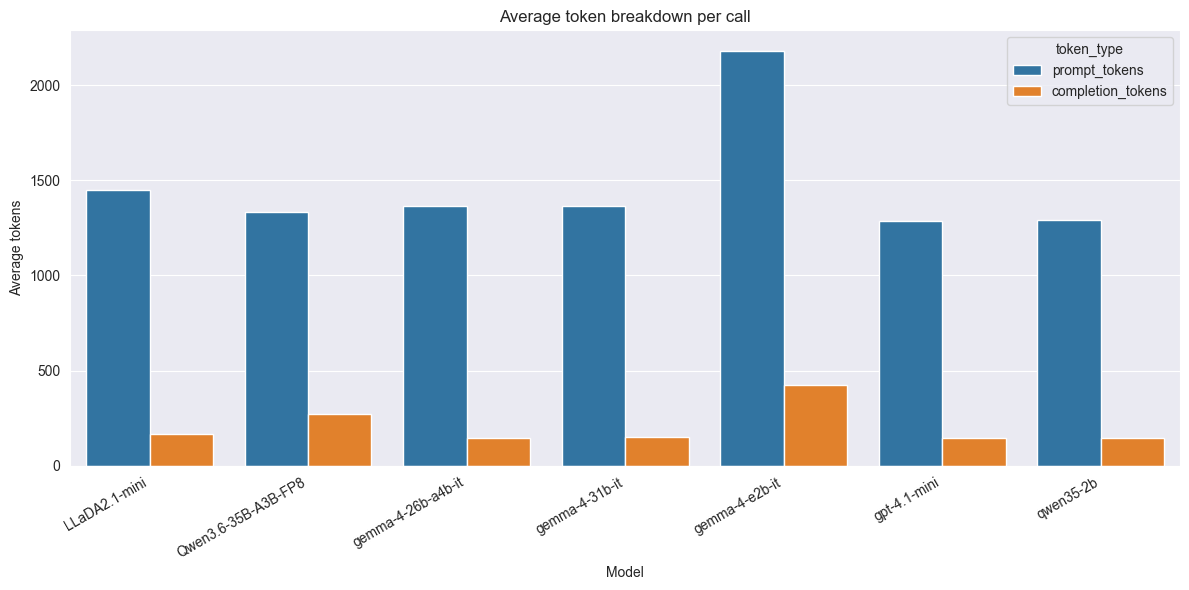

In [5]:
global_token_summary = (
    latency_df
    .groupby('model')[token_cols]
    .agg(['mean', 'median', 'std', 'count'])
    .sort_index()
)
display(round_df(global_token_summary))

global_token_means = (
    latency_df
    .groupby('model', as_index=False)[token_cols]
    .mean(numeric_only=True)
)

plot_df = global_token_means.melt(
    id_vars='model',
    value_vars=['prompt_tokens', 'completion_tokens'],
    var_name='token_type',
    value_name='avg_tokens',
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='avg_tokens', hue='token_type')
plt.xticks(rotation=30, ha='right')
plt.title('Average token breakdown per call')
plt.xlabel('Model')
plt.ylabel('Average tokens')
plt.tight_layout()
plt.show()

---
## Latency Statistics

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.072,0.065,0.022,0.046,0.140,0.122,30
Qwen3.6-35B-A3B-FP8,0.597,0.262,1.752,0.225,9.872,0.371,30
gemma-4-26b-a4b-it,0.271,0.254,0.043,0.219,0.432,0.341,30
gemma-4-31b-it,0.481,0.478,0.060,0.395,0.626,0.593,30
gemma-4-e2b-it,0.430,0.194,0.610,0.159,2.216,1.993,30
gpt-4.1-mini,0.627,0.621,0.070,0.516,0.835,0.734,30
qwen35-2b,0.249,0.169,0.308,0.147,1.949,0.568,60


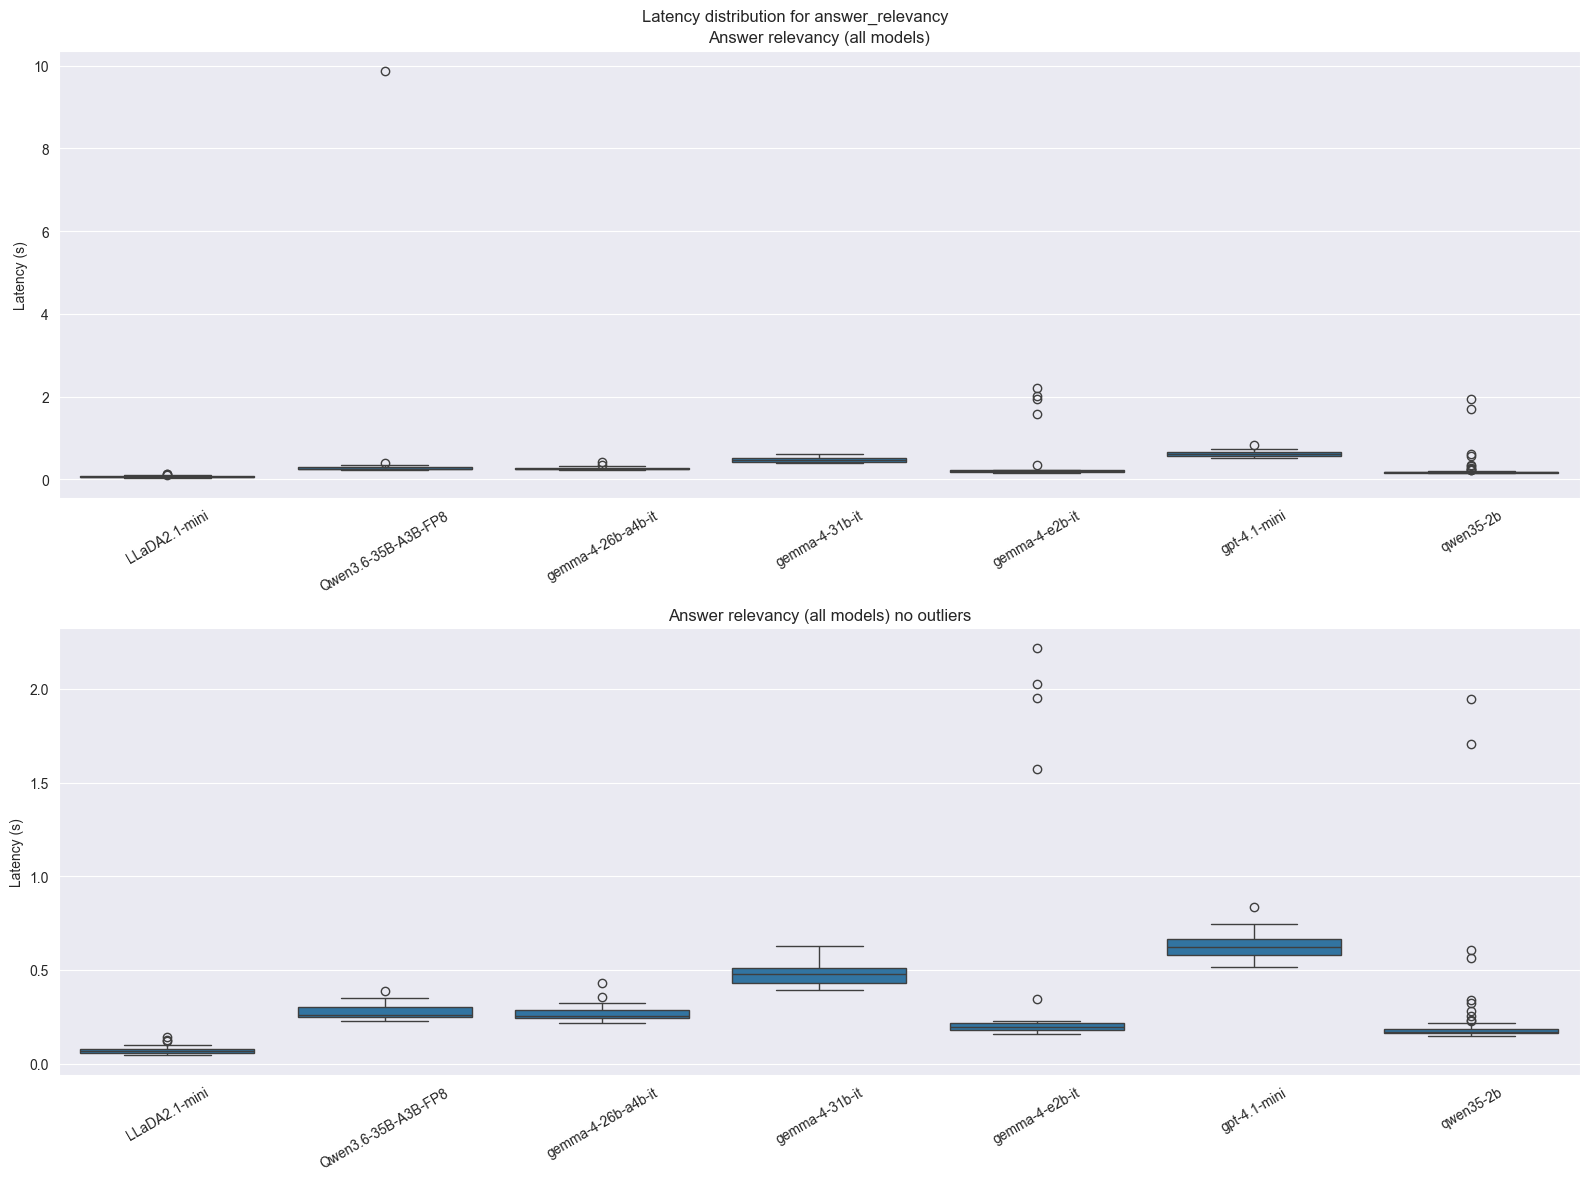

In [6]:
metric_names = ['answer_relevancy']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]




metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False, sharey=False)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[0])
axes[0].set_title('Answer relevancy (all models)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Latency (s)')
axes[0].tick_params(axis='x', rotation=30)

# lets filter out all rows which have latency more than 6s
metric_df = metric_df[metric_df['latency_s'] <= 6]
metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[1])
axes[1].set_title('Answer relevancy (all models) no outliers')
axes[1].set_xlabel('')
axes[1].set_ylabel('Latency (s)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Latency distribution for answer_relevancy')
fig.tight_layout()
plt.show()

In [7]:
metric_df

,case_id,example_idx,question,metric_name,call_index,prompt,response_model,response,latency_s,prompt_tokens,completion_tokens,total_tokens,cached_tokens,reasoning_tokens,timestamp,model,model_dir,source_file
394,AR1,0,What is LLM-as-a-judge and how does it work?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='How does LLM-as-a-judge evaluate AI ...,0.1239,750,38,788,0,0,2026-06-11T05:26:10.139040+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260611_072610_LLaDA2.1-mini_answer-relevancy...
395,AR2,1,What are the three layers of continual learnin...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are the three layers of which l...,0.1399,766,38,804,0,0,2026-06-11T05:26:10.914203+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260611_072610_LLaDA2.1-mini_answer-relevancy...
396,AR3,2,What is agent observability?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What is agent observability in the c...,0.0594,736,37,773,0,0,2026-06-11T05:26:11.395659+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260611_072610_LLaDA2.1-mini_answer-relevancy...
397,AR4,3,What biases affect LLM-as-a-judge evaluators?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are the known biases in LLM jud...,0.0700,754,41,795,0,0,2026-06-11T05:26:11.860672+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260611_072610_LLaDA2.1-mini_answer-relevancy...
398,AR5,4,What is trajectory evaluation and why is it im...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='Why is trajectory evaluation importa...,0.0553,752,35,787,0,0,2026-06-11T05:26:12.454177+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260611_072610_LLaDA2.1-mini_answer-relevancy...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,AR26,25,Should I use LLM-as-a-judge or human evaluatio...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are the key factors that determ...,0.1769,717,44,761,0,0,2026-06-11T05:56:24.621831+00:00,qwen35-2b,qwen35-2b,20260611_075607_qwen35-2b_answer-relevancy-tes...
3078,AR27,26,What evaluation metrics should I prioritize fo...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are some of the RAG evaluation ...,0.1696,718,41,759,0,0,2026-06-11T05:56:25.213097+00:00,qwen35-2b,qwen35-2b,20260611_075607_qwen35-2b_answer-relevancy-tes...
3079,AR28,27,Is trajectory evaluation worth the overhead fo...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='Is overhead from trajectory evaluati...,0.1589,724,35,759,0,0,2026-06-11T05:56:25.881152+00:00,qwen35-2b,qwen35-2b,20260611_075607_qwen35-2b_answer-relevancy-tes...
3080,AR29,28,How often should I retrain my agent using cont...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What is the frequency of retraining ...,0.1645,720,36,756,0,0,2026-06-11T05:56:26.469081+00:00,qwen35-2b,qwen35-2b,20260611_075607_qwen35-2b_answer-relevancy-tes...


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.167,0.166,0.060,0.061,0.341,0.267,84
Qwen3.6-35B-A3B-FP8,0.171,0.167,0.024,0.144,0.348,0.187,84
gemma-4-26b-a4b-it,0.203,0.187,0.055,0.150,0.393,0.337,84
gemma-4-31b-it,0.392,0.338,0.135,0.231,0.703,0.621,84
gemma-4-e2b-it,1.012,0.155,1.855,0.122,11.985,4.197,84
gpt-4.1-mini,0.601,0.421,1.521,0.357,14.363,0.555,84
qwen35-2b,0.191,0.196,0.073,0.115,0.378,0.335,84


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.167,0.166,0.060,0.061,0.341,0.267,84
gemma-4-26b-a4b-it,0.203,0.187,0.055,0.150,0.393,0.337,84
gemma-4-31b-it,0.392,0.338,0.135,0.231,0.703,0.621,84
qwen35-2b,0.191,0.196,0.073,0.115,0.378,0.335,84


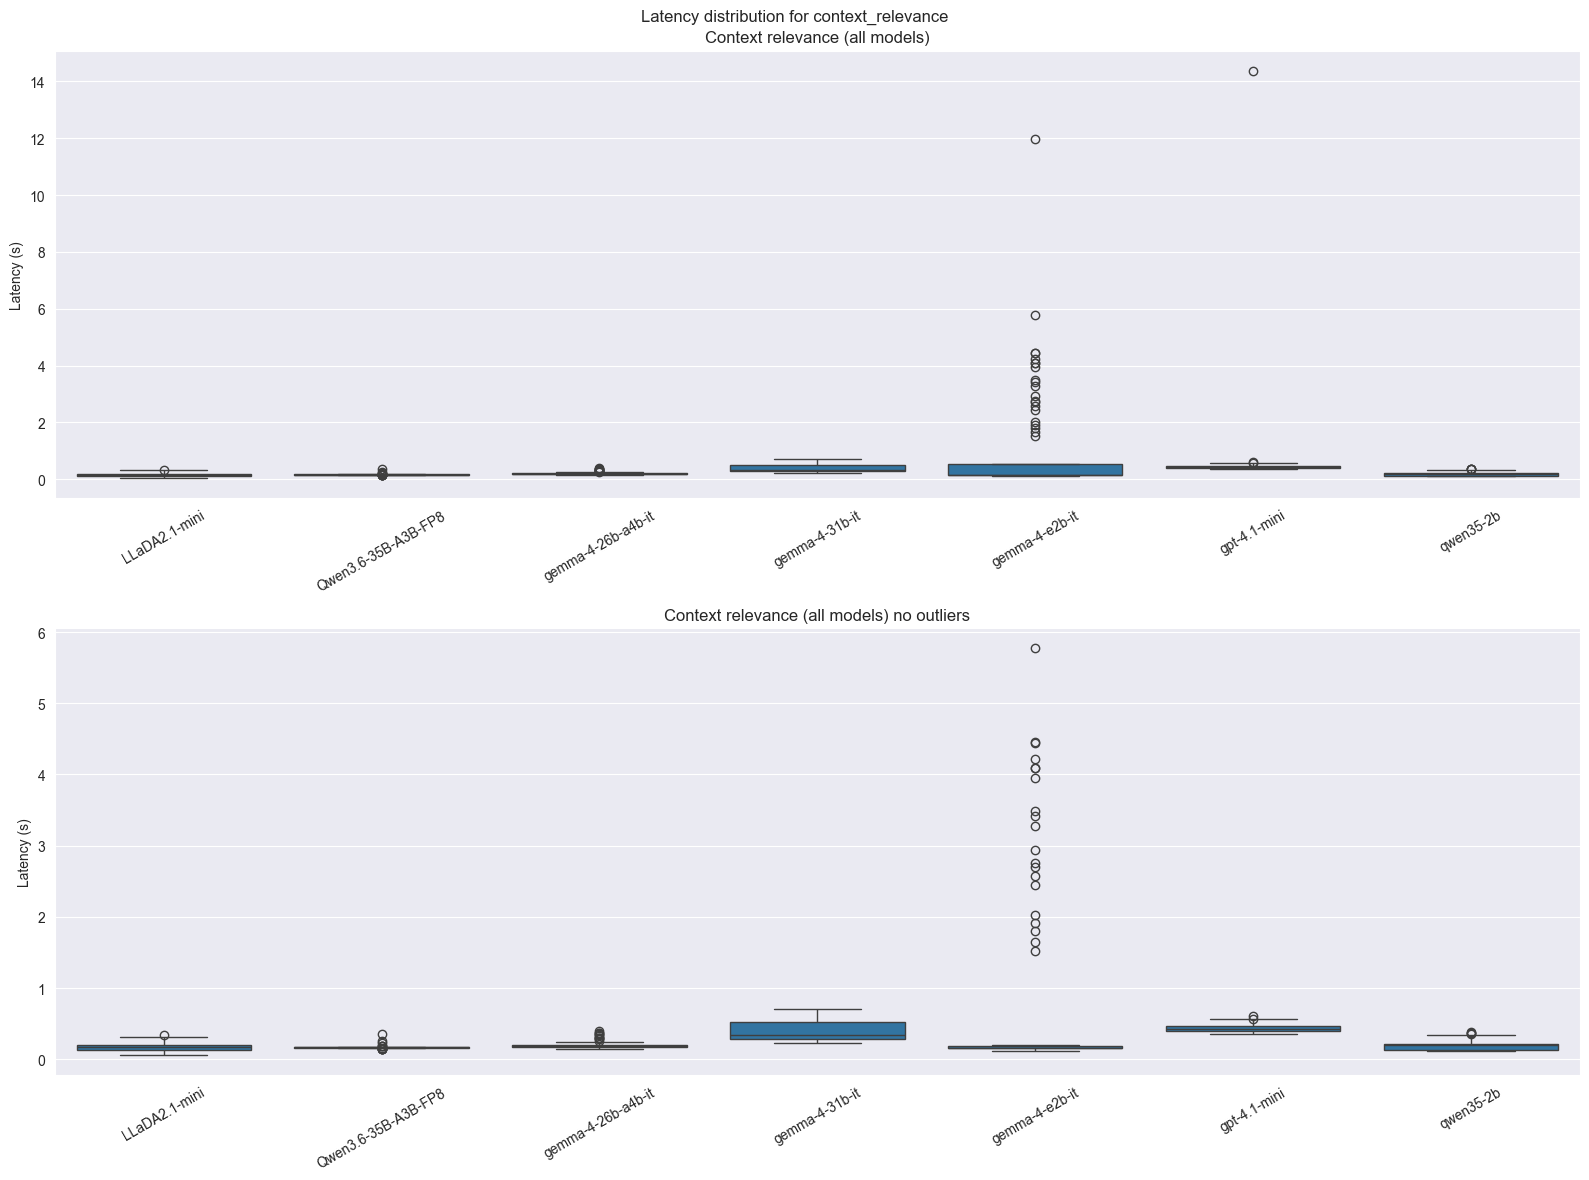

In [8]:
metric_names = ['context_relevance']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

excluded_models = {'Qwen3.6-35B-A3B-FP8', 'gemma-4-e2b-it'}
excluded_models.add('gpt-4.1-mini')
filtered_df = metric_df[~metric_df['model'].isin(excluded_models)]
metric_summary_filtered = (
    filtered_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_filtered))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False, sharey=False)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[0])
axes[0].set_title('Context relevance (all models)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Latency (s)')
axes[0].tick_params(axis='x', rotation=30)

metric_df = metric_df[metric_df['latency_s'] <= 6]

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[1])
axes[1].set_title('Context relevance (all models) no outliers')
axes[1].set_xlabel('')
axes[1].set_ylabel('Latency (s)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Latency distribution for context_relevance')
fig.tight_layout()
plt.show()

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.164,0.164,0.063,0.061,0.295,0.275,94
Qwen3.6-35B-A3B-FP8,0.166,0.165,0.012,0.143,0.229,0.173,94
gemma-4-26b-a4b-it,0.180,0.181,0.016,0.152,0.233,0.207,94
gemma-4-31b-it,0.398,0.347,0.166,0.227,0.813,0.738,94
gemma-4-e2b-it,1.852,0.163,2.622,0.123,17.138,5.650,94
gpt-4.1-mini,0.581,0.417,1.441,0.359,14.393,0.550,94
qwen35-2b,0.210,0.208,0.076,0.115,0.393,0.329,94


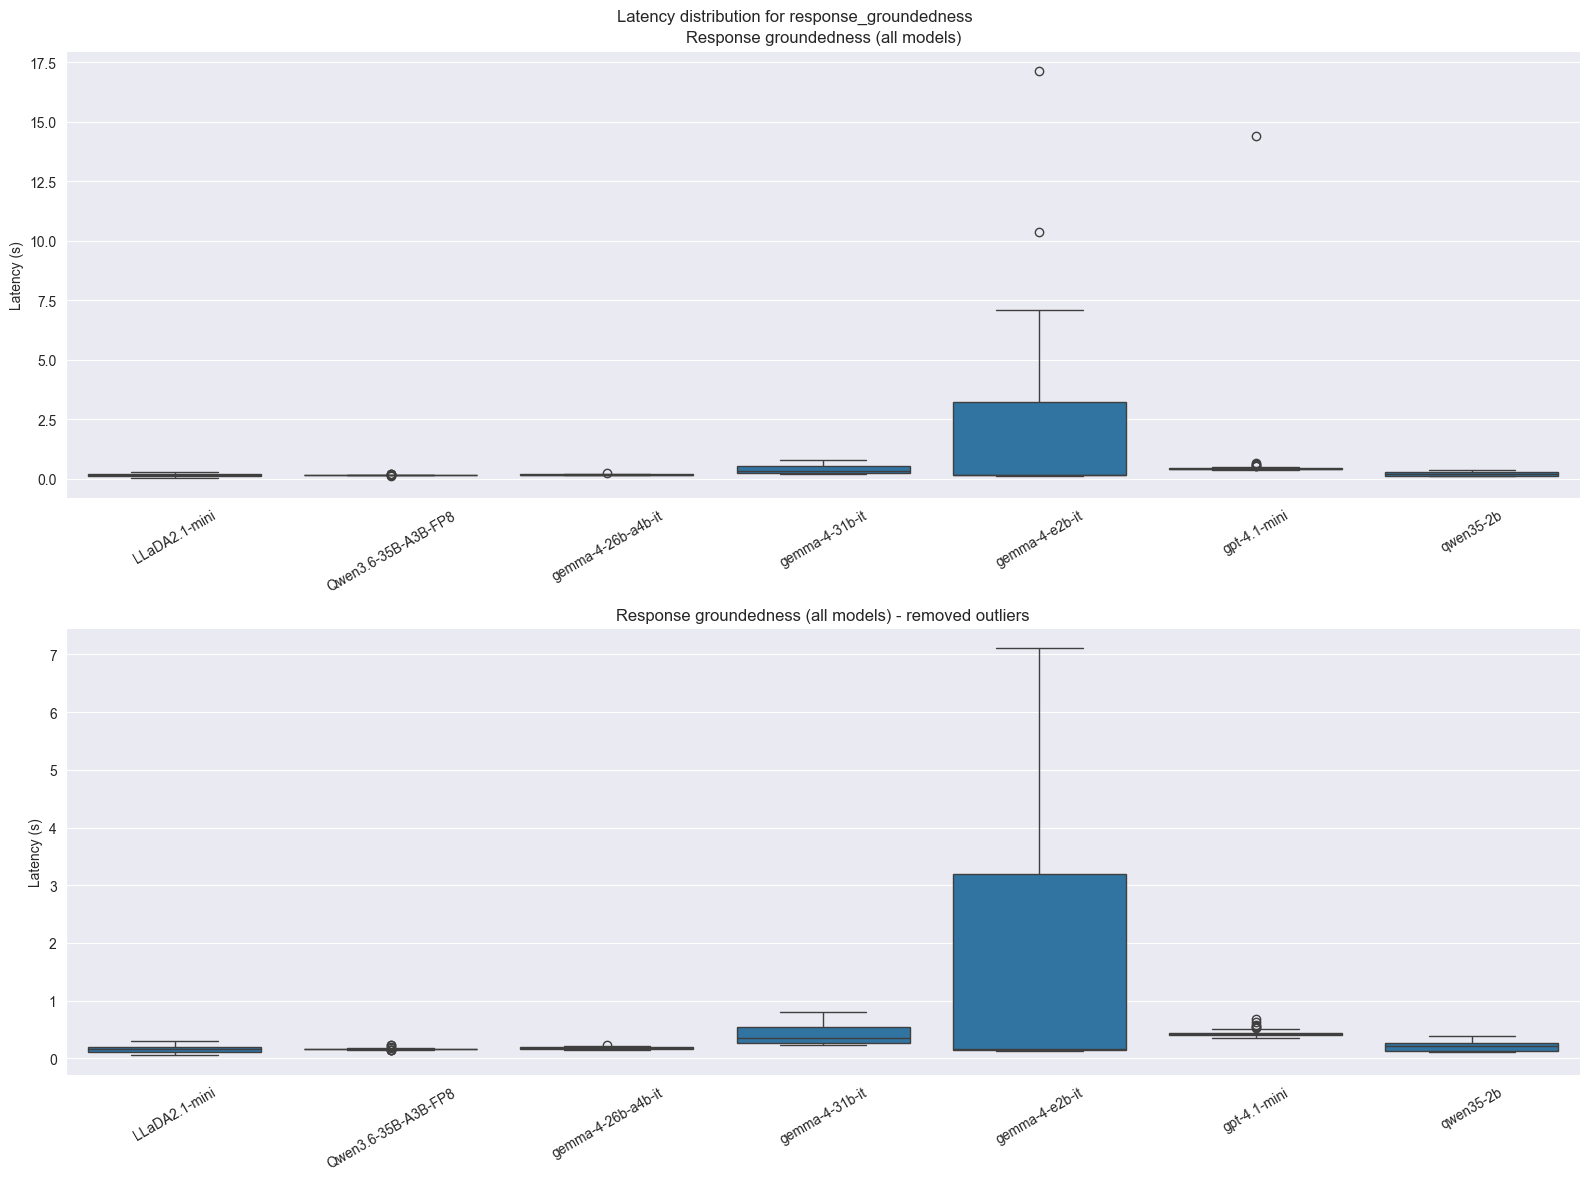

In [9]:
metric_names = ['response_groundedness']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False, sharey=False)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[0])
axes[0].set_title('Response groundedness (all models)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Latency (s)')
axes[0].tick_params(axis='x', rotation=30)

metric_df = metric_df[metric_df['latency_s'] <= 7.5]
metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[1])
axes[1].set_title('Response groundedness (all models) - removed outliers')
axes[1].set_xlabel('')
axes[1].set_ylabel('Latency (s)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Latency distribution for response_groundedness')
fig.tight_layout()
plt.show()

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.184,0.171,0.080,0.086,0.721,0.299,88
gemma-4-26b-a4b-it,1.008,0.751,1.041,0.417,9.602,1.862,88
gemma-4-31b-it,1.876,1.586,1.426,0.765,10.460,3.097,88
gemma-4-e2b-it,2.673,2.265,2.641,0.284,16.321,6.046,88
gpt-4.1-mini,0.896,0.692,1.804,0.575,17.606,0.889,88
qwen35-2b,0.857,0.777,0.976,0.231,9.113,1.505,88


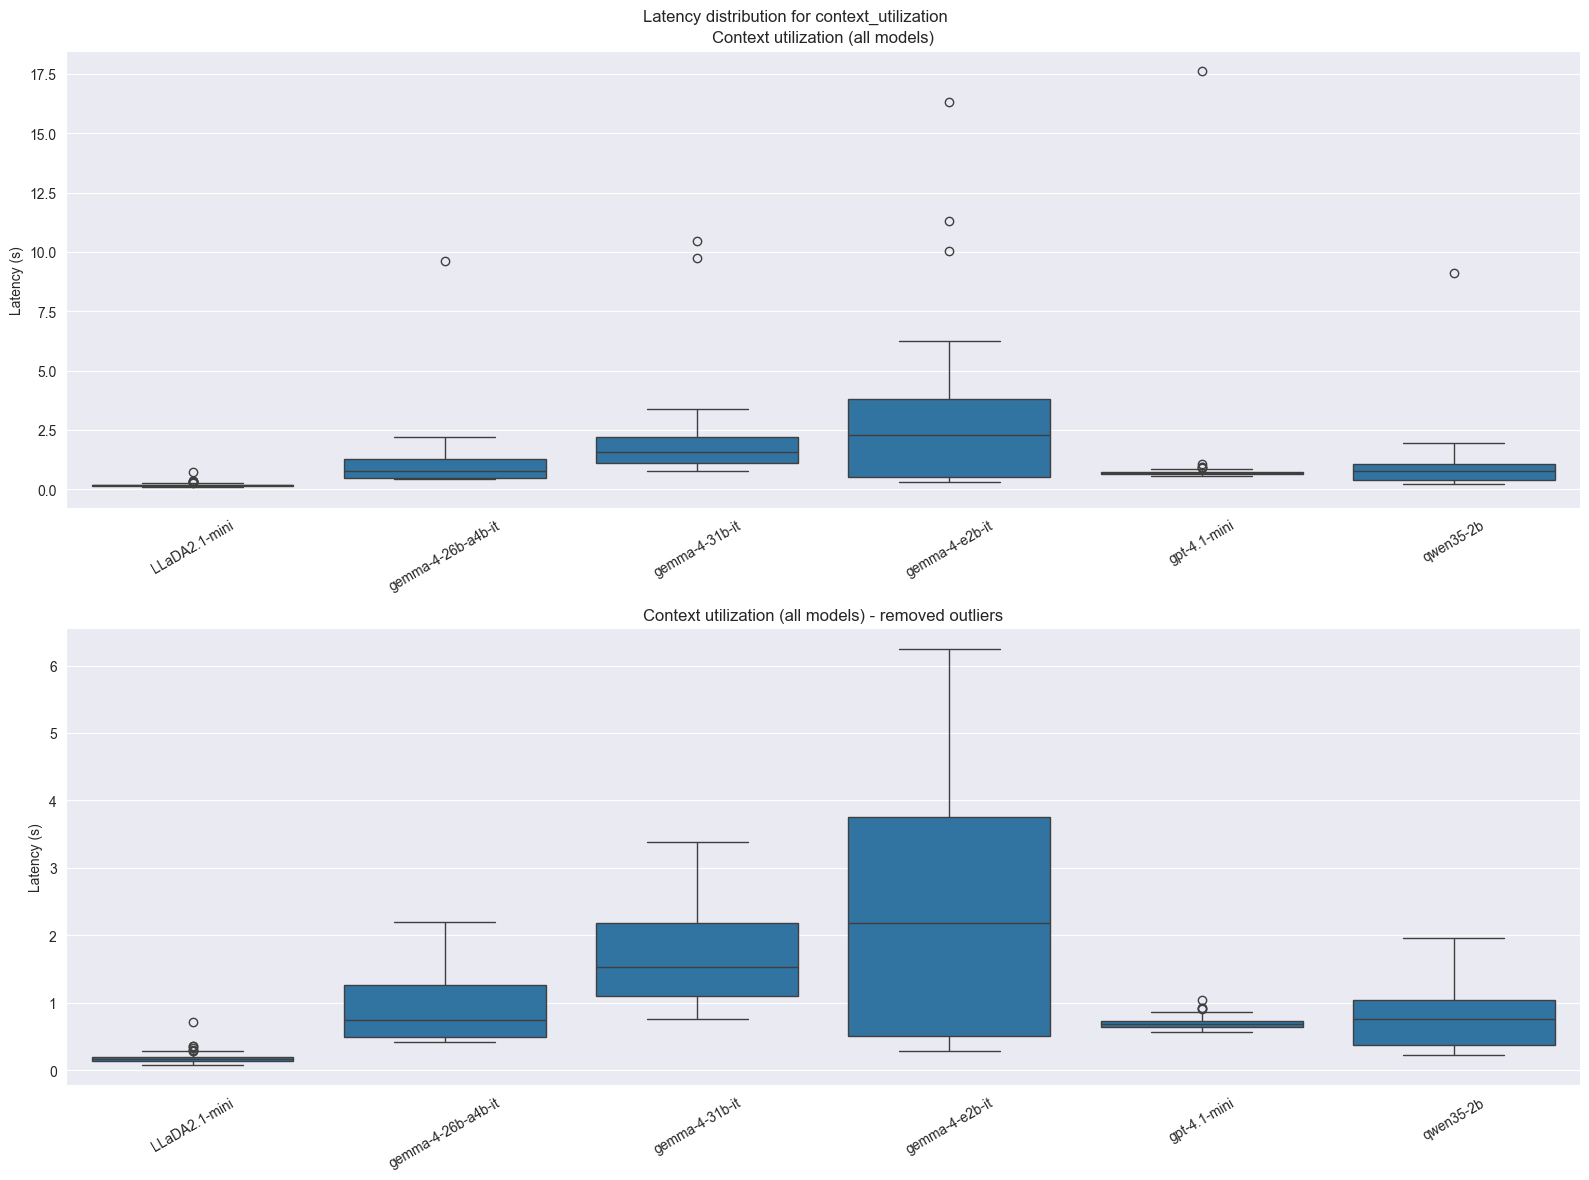

In [10]:
metric_names = ['context_utilization']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False, sharey=False)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[0])
axes[0].set_title('Context utilization (all models)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Latency (s)')
axes[0].tick_params(axis='x', rotation=30)

# without outliers
metric_df = metric_df[metric_df['latency_s'] <= 7]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[1])
axes[1].set_title('Context utilization (all models) - removed outliers')
axes[1].set_xlabel('')
axes[1].set_ylabel('Latency (s)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Latency distribution for context_utilization')
fig.tight_layout()
plt.show()

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.624,0.454,0.894,0.073,9.417,1.413,128
Qwen3.6-35B-A3B-FP8,2.486,1.541,2.535,0.274,18.781,6.343,268
gemma-4-26b-a4b-it,5.161,2.816,5.574,0.276,36.260,15.964,135
gemma-4-31b-it,8.280,5.527,7.654,0.462,38.847,24.553,135
gemma-4-e2b-it,6.006,3.674,6.441,0.203,39.240,18.793,133
gpt-4.1-mini,2.727,1.737,2.994,0.504,22.100,6.271,135
qwen35-2b,3.319,1.924,3.939,0.325,22.291,11.628,134


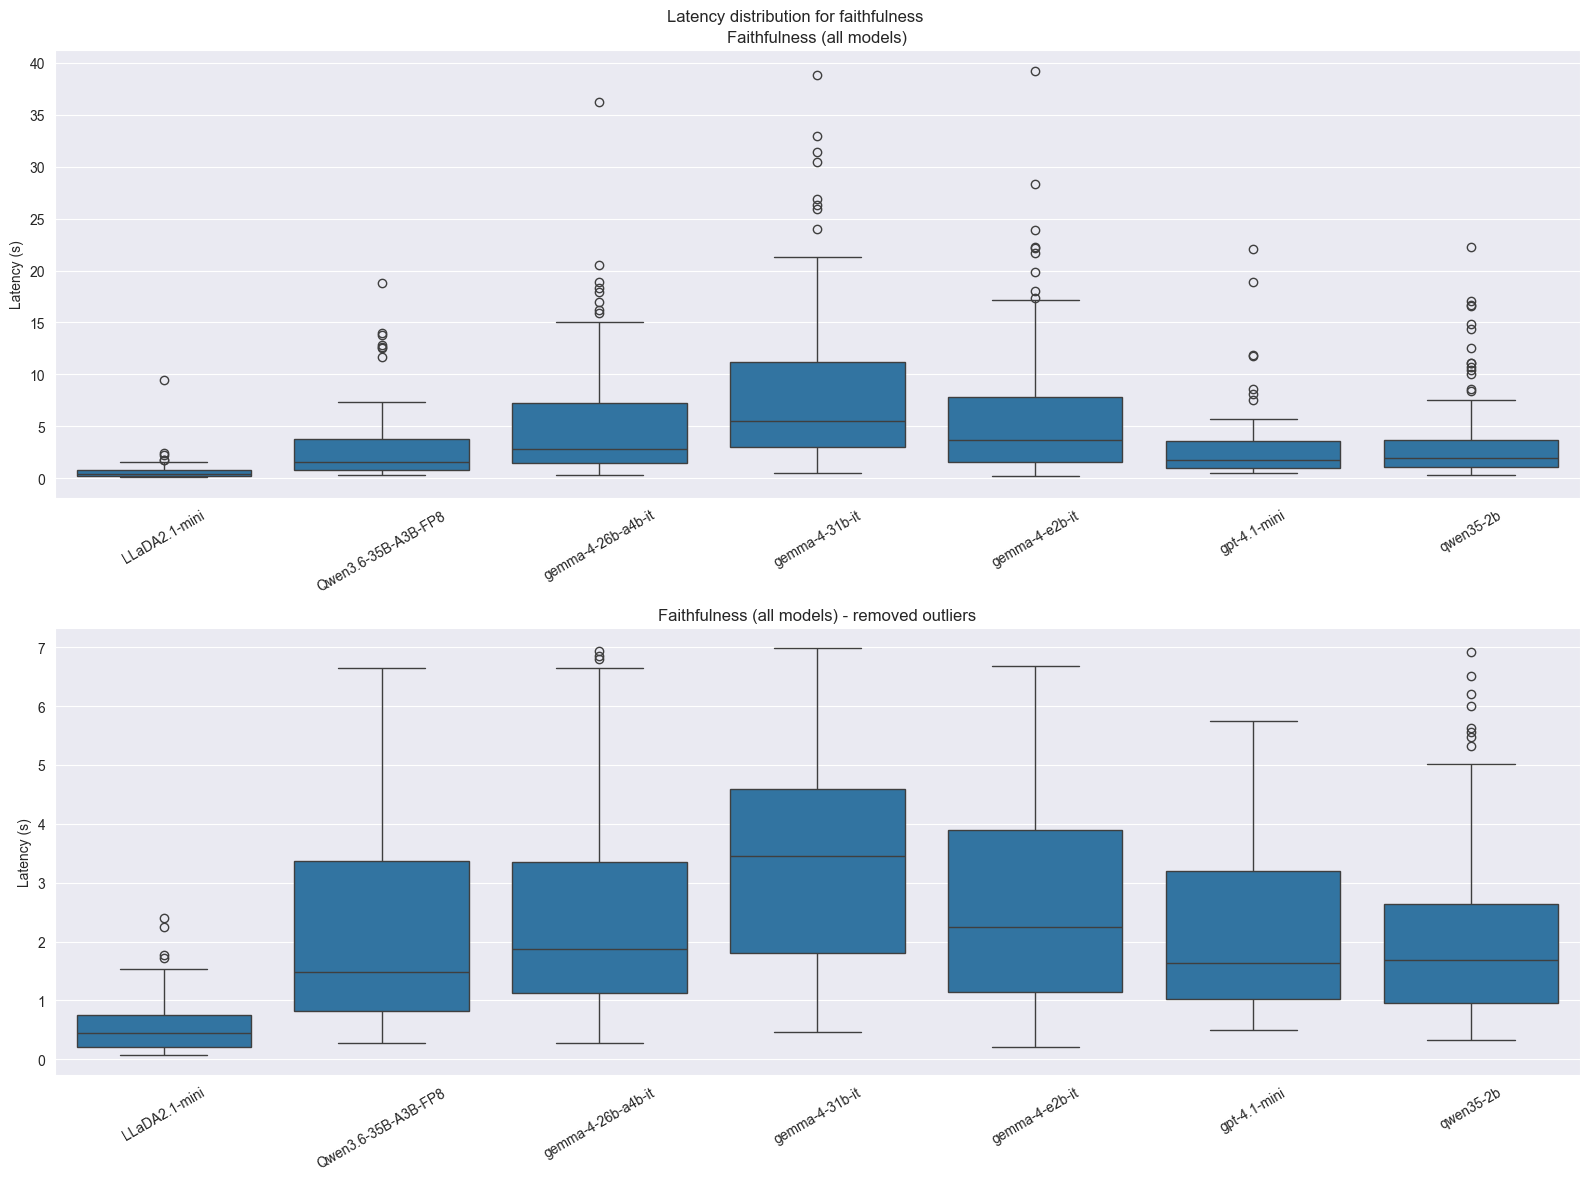

In [11]:
metric_names = ['faithfulness_exp1', 'faithfulness_exp2']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False, sharey=False)

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[0])
axes[0].set_title('Faithfulness (all models)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Latency (s)')
axes[0].tick_params(axis='x', rotation=30)

metric_df = metric_df[metric_df['latency_s'] <= 7]

sns.boxplot(data=metric_df, x='model', y='latency_s', ax=axes[1])
axes[1].set_title('Faithfulness (all models) - removed outliers')
axes[1].set_xlabel('')
axes[1].set_ylabel('Latency (s)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Latency distribution for faithfulness')
fig.tight_layout()
plt.show()

# observacije - ovaj graf je jedini koristan za latencije, jer ima razlika i output je ipak veci, pogtoov za high granularity

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,1.153,0.902,1.342,0.423,9.417,2.174,44
Qwen3.6-35B-A3B-FP8,3.995,4.005,2.665,1.160,18.781,6.963,90
gemma-4-26b-a4b-it,8.850,5.465,7.185,1.416,36.260,18.812,45
gemma-4-31b-it,13.281,10.750,7.549,2.756,32.936,29.722,45
gemma-4-e2b-it,9.494,6.676,8.013,0.968,39.240,22.149,45
gpt-4.1-mini,4.424,4.311,3.462,1.419,22.100,8.483,45
qwen35-2b,6.255,4.339,5.058,0.611,22.291,16.351,44


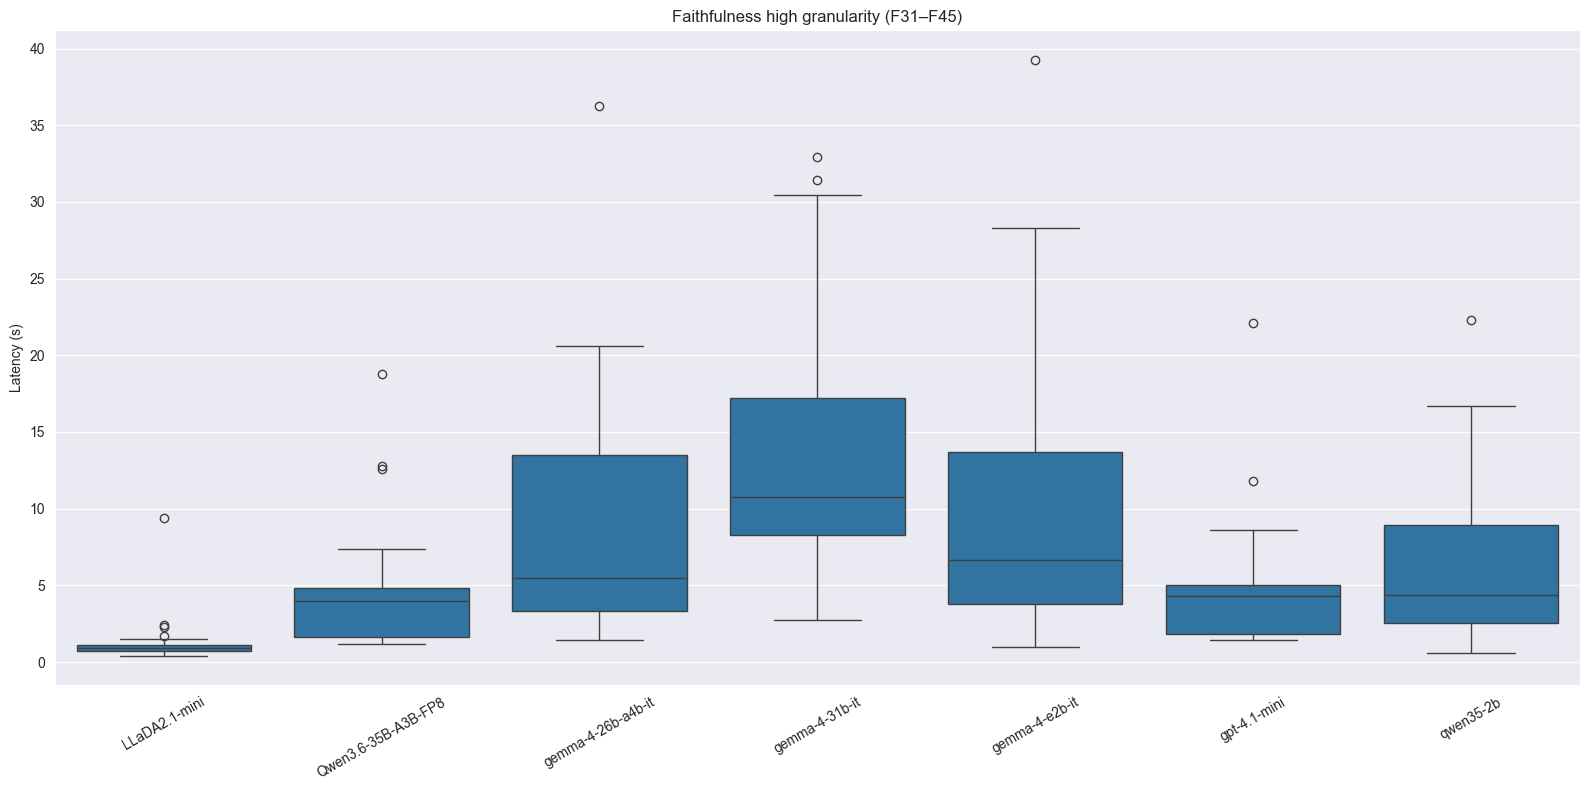

In [21]:
metric_names = ['faithfulness_exp1', 'faithfulness_exp2']
metric_df = latency_df[latency_df['metric_name'].isin(metric_names)]

high_granularity = ['F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45']
metric_df = metric_df[metric_df['case_id'].isin(high_granularity)]

metric_summary_all = (
    metric_df
    .groupby('model')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(metric_summary_all))

fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(data=metric_df, x='model', y='latency_s', ax=ax)
ax.set_title('Faithfulness high granularity (F31–F45)')
ax.set_xlabel('')
ax.set_ylabel('Latency (s)')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

---
## Optional Export

In [12]:
task_token_summary.to_csv(RESULTS_DIR / 'token_latency_task_summary.csv')
global_token_summary.to_csv(RESULTS_DIR / 'token_latency_global_summary.csv')
latency_overall_by_metric.to_csv(RESULTS_DIR / 'token_latency_latency_summary.csv')
print('Saved summary CSVs to results/')

Saved summary CSVs to results/
